# **Homework 4**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

### **Importing Required Libraries**

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import gzip
import struct

## **Step 1: Data Acquisition and Visualization**

In [19]:
def read_idx(filename):
    with gzip.open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

In [20]:
# Load training and test data
train_images = read_idx('train-images-idx3-ubyte.gz')
train_labels = read_idx('train-labels-idx1-ubyte.gz')
test_images = read_idx('t10k-images-idx3-ubyte.gz')
test_labels = read_idx('t10k-labels-idx1-ubyte.gz')

train_images.shape

(60000, 28, 28)

In [21]:
train_labels.shape

(60000,)

In [22]:
test_images.shape

(10000, 28, 28)

In [23]:
test_labels.shape

(10000,)

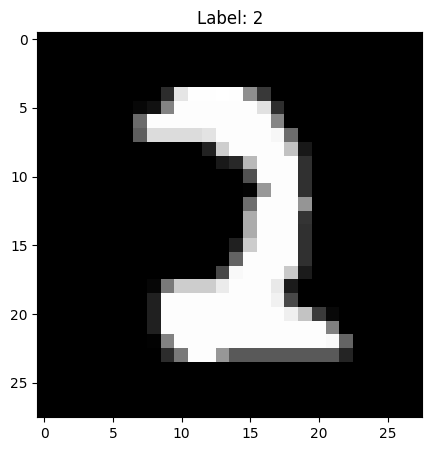

In [24]:
# (b) Visualize a random sample
np.random.seed(695)
random_idx = np.random.randint(0, len(train_images))
img = train_images[random_idx]
label = train_labels[random_idx]
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

### **Observation:**
The dataset consists of grayscale 28x28 images of digits (0-9). Each image is labeled accordingly.


## **Step 2: Data Preprocessing**

In [25]:
# (a) Normalize pixel values to be between 0 and 1
X_train = train_images.astype('float32') / 255.0
X_test = test_images.astype('float32') / 255.0

# (b) Convert labels to one-hot encoding
y_train = np.eye(10)[train_labels]
y_test = np.eye(10)[test_labels]

print(f"Original label: {train_labels[random_idx]}")
print(f"One-hot encoded label: {y_train[random_idx]}")

Original label: 2
One-hot encoded label: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


### **Insight:**
Normalizing the pixel values ensures that the model converges faster. One-hot encoding is crucial for multi-class classification using softmax.


## **Step 3: Network Initialization**

In [26]:
# (a) Define activation functions and their derivatives
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

def softmax(z):
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [27]:
# (b) Initialize network parameters
# Set seed for reproducibility
np.random.seed(695)
input_size = 28 * 28  # 784
hidden1_size = 128
hidden2_size = 64
output_size = 10  # 10 classes

# Initialize weights and biases
W1 = np.random.uniform(-0.1, 0.1, (input_size, hidden1_size))
b1 = np.zeros((1, hidden1_size))
W2 = np.random.uniform(-0.1, 0.1, (hidden1_size, hidden2_size))
b2 = np.zeros((1, hidden2_size))
W3 = np.random.uniform(-0.1, 0.1, (hidden2_size, output_size))
b3 = np.zeros((1, output_size))

print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"b2 shape: {b2.shape}")
print(f"W3 shape: {W3.shape}")
print(f"b3 shape: {b3.shape}")

W1 shape: (784, 128)
b1 shape: (1, 128)
W2 shape: (128, 64)
b2 shape: (1, 64)
W3 shape: (64, 10)
b3 shape: (1, 10)


### **Explanation:**
- We use small random weights to break symmetry and prevent neurons from learning the same function.
- The biases are initialized to zero.

## **Step 4: Feed Forward**

In [28]:
def feed_forward(X, W1, b1, W2, b2, W3, b3):
    # Make sure input is flattened
    if len(X.shape) > 2:
        X = X.reshape(X.shape[0], -1)
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    cache = {
        'X': X, 'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3, 'A3': A3
    }

    return A3, cache

## **Step 5: Back Propagation**

In [29]:
# (a) Categorical cross entropy loss function
def categorical_crossentropy(y_true, y_pred):
    n_samples = y_true.shape[0]
    y_pred_clipped = np.clip(y_pred, 1e-12, 1 - 1e-12)
    return -np.sum(y_true * np.log(y_pred_clipped)) / n_samples

In [30]:
# (b) Backpropagation implementation
def backpropagation(X, y, cache, W1, W2, W3):
    m = X.shape[0]

    # Output layer error
    dZ3 = cache['A3'] - y
    dW3 = (1/m) * np.dot(cache['A2'].T, dZ3)
    db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

    # Hidden layer 2 error
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * sigmoid_derivative(cache['A2'])
    dW2 = (1/m) * np.dot(cache['A1'].T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer 1 error
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(cache['A1'])
    dW1 = (1/m) * np.dot(cache['X'].T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2, dW3, db3

## **Step 6: Model Training with Mini-Batch Gradient Descent**

In [31]:
# Flatten input images
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Training settings
batch_size = 128
epochs = 100
learning_rate = 0.1
n_samples = X_train_flat.shape[0]

# Trscker
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

# Begin training
for epoch in range(epochs):
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    X_shuffled = X_train_flat[indices]
    y_shuffled = y_train[indices]

    # Mini-batch training
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        A3, cache = feed_forward(X_batch, W1, b1, W2, b2, W3, b3) # Forward pass
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(X_batch, y_batch, cache, W1, W2, W3) # Backward pass

        # Update parameters
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    # Training metrics
    train_preds, train_cache = feed_forward(X_train_flat, W1, b1, W2, b2, W3, b3)
    train_loss = categorical_crossentropy(y_train, train_preds)
    train_acc = np.mean(np.argmax(y_train, axis=1) == np.argmax(train_preds, axis=1))

    # Validation metrics
    val_preds, val_cache = feed_forward(X_test_flat, W1, b1, W2, b2, W3, b3)
    val_loss = categorical_crossentropy(y_test, val_preds)
    val_acc = np.mean(np.argmax(y_test, axis=1) == np.argmax(val_preds, axis=1))

    # Store metrics in array
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss}, Train Acc: {train_acc}, Val Loss: {val_loss}, Val Acc: {val_acc}")

Epoch 10/100, Train Loss: 0.3000362842171729, Train Acc: 0.9144833333333333, Val Loss: 0.29660522992397637, Val Acc: 0.9157
Epoch 20/100, Train Loss: 0.20086046439897684, Train Acc: 0.943, Val Loss: 0.20535483341841804, Val Acc: 0.9403
Epoch 30/100, Train Loss: 0.14331207183456163, Train Acc: 0.9588333333333333, Val Loss: 0.15377231111549103, Val Acc: 0.9544
Epoch 40/100, Train Loss: 0.10983684788364616, Train Acc: 0.9691833333333333, Val Loss: 0.12444168635398517, Val Acc: 0.9636
Epoch 50/100, Train Loss: 0.0883338175219163, Train Acc: 0.9752, Val Loss: 0.10907148438585677, Val Acc: 0.968
Epoch 60/100, Train Loss: 0.07247908785675995, Train Acc: 0.9799333333333333, Val Loss: 0.09753718345459779, Val Acc: 0.9714
Epoch 70/100, Train Loss: 0.06088760744768871, Train Acc: 0.9836666666666667, Val Loss: 0.0897749213558817, Val Acc: 0.9744
Epoch 80/100, Train Loss: 0.049843052933342354, Train Acc: 0.9869166666666667, Val Loss: 0.0829581150245691, Val Acc: 0.9759
Epoch 90/100, Train Loss: 0.0

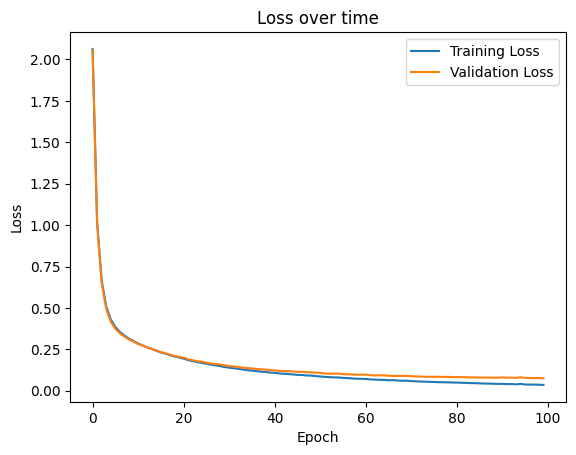

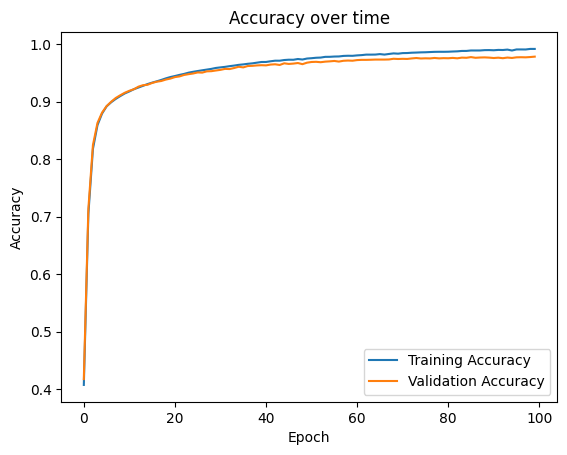

In [33]:
# Plot loss
plt.figure()
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over time')
plt.legend()
plt.show()
# Plot accuracy
plt.figure()
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over time')
plt.legend()
plt.show()

## **Step 7: Model Evaluation**

In [34]:
# (a) Evaluate model on test data
final_preds, _ = feed_forward(X_test_flat, W1, b1, W2, b2, W3, b3)
pred_labels = np.argmax(final_preds, axis=1)
true_labels = np.argmax(y_test, axis=1)
test_accuracy = np.mean(pred_labels == true_labels)

print("Test accuracy: ",test_accuracy)

# Find misclassified samples
misclassified_indices = np.where(pred_labels != true_labels)[0]
print("Number of misclassified samples: ",len(misclassified_indices))

Test accuracy:  0.9785
Number of misclassified samples:  215


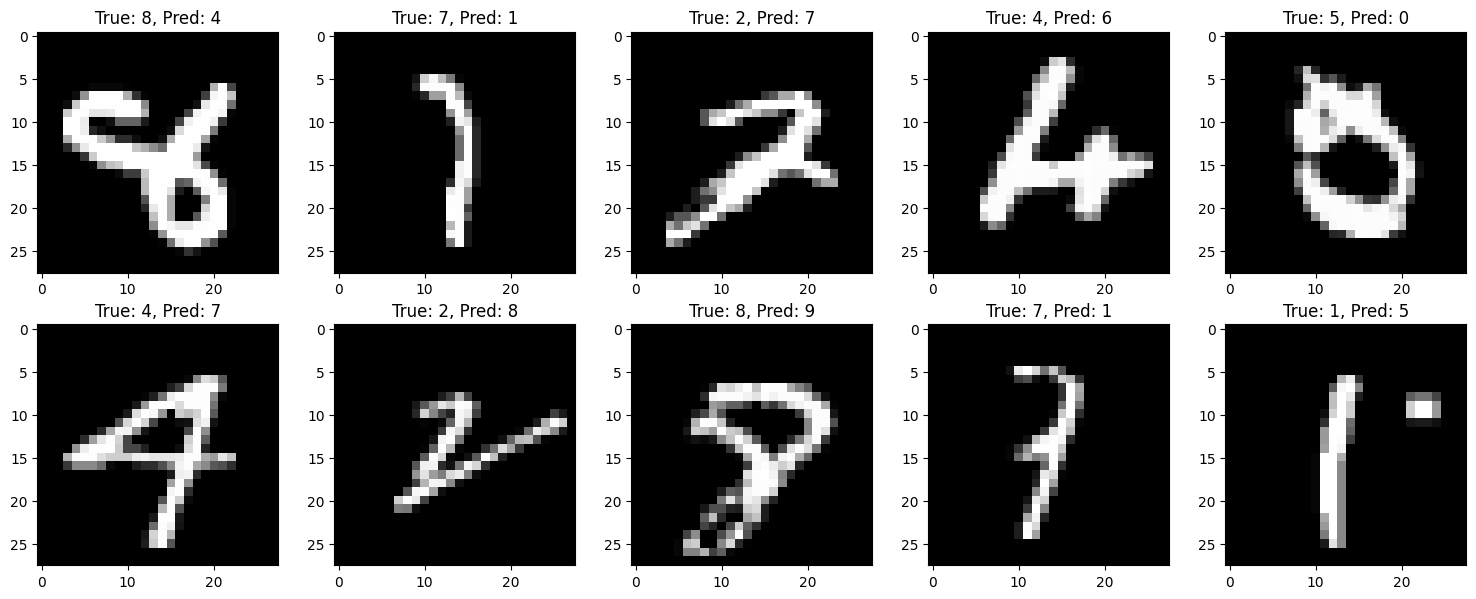

In [35]:
# (b) Plot some misclassified examples
if len(misclassified_indices) > 0:
    # Display up to 10 misclassified examples
    n_samples = min(10, len(misclassified_indices))
    sample_indices = np.random.choice(misclassified_indices, n_samples, replace=False)

    # Create plot with subplots
    rows = int(np.ceil(n_samples / 5))
    cols = min(5, n_samples)

    plt.figure(figsize=(15, 3 * rows))
    for i, idx in enumerate(sample_indices):
        img = X_test[idx].reshape(28, 28)
        true_label = true_labels[idx]
        pred_label = pred_labels[idx]

        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {true_label}, Pred: {pred_label}')

    plt.tight_layout()
    plt.show()